# Fiducial Theory Datavector and Pasted-Map Cl Validation

This notebook builds or loads the first SBI-validation products:

- Fiducial theory datavector: `gg`, `gy`, `gtau`, `gkappa`.
- Gaussian covariance and correlation matrix.
- Pasted-map Cl measurements from the Backlight `nside=512` maps.
- Raw pixel-windowed and deconvolved signal-space map/theory comparisons.

The Backlight HDF mass column is converted from its source particle-count mass convention to the GODMAX theory mass units before both theory and map generation are compared. The notebook also applies the source ASDF cosmology and lowers the theory halo-mass grid below the converted catalog minimum.

`map_rhom` is treated only as a diagnostic. It is not compared to `Cl_gkappa`.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

from backlight_metadata import backlight_validation_settings
from fiducial_theory_datavector import (
    DEFAULT_OUTPUT as THEORY_OUTPUT,
    build_and_save_fiducial,
    load_validation_product,
)
from gaussian_covariance import covariance_quality_checks
from pasted_map_cls_validation import (
    DEFAULT_VALIDATION_OUTPUT as MAP_VALIDATION_OUTPUT,
    DEFAULT_MAP_PATH,
    DEFAULT_HALO_CATALOG,
    measure_pasted_map_cls,
    load_map_validation_product,
)

plt.rcParams.update({"font.size": 13})

In [1]:
# Toggle these if you want to force recomputation. Even with these False,
# stale pre-mass-conversion products are automatically rebuilt.
REGENERATE_THEORY = False
REGENERATE_MAP_VALIDATION = False
REGENERATE_PASTED_MAPS = False

GAL_ZMIN = 0.4
GAL_ZMAX = 0.6
NBAR_COMOVING = 1.0e-4
RAW_HALO_MASS_CUT = 1.0e13
NSIDE = 512

# Use 'cmb' to match the current Backlight lensing-map convention.
# Use 'lsst' for an effective one-bin LSST source kernel in theory-only tests.
KAPPA_SOURCE = "cmb"

BACKLIGHT_SETTINGS = backlight_validation_settings(DEFAULT_HALO_CATALOG)
HOD_MASS_CUT = float(BACKLIGHT_SETTINGS["hod_mass_cut"])
SIM_PARAM_OVERRIDES = dict(BACKLIGHT_SETTINGS["sim_param_overrides"])
HALO_PARAM_OVERRIDES = dict(BACKLIGHT_SETTINGS["halo_param_overrides"])
BACKLIGHT_EXTRA_METADATA = {
    "backlight_mass_corrected": True,
    "backlight_source_metadata": BACKLIGHT_SETTINGS["source_metadata"],
    "backlight_mass_metadata": BACKLIGHT_SETTINGS["mass_metadata"],
    "backlight_raw_halo_mass_cut": RAW_HALO_MASS_CUT,
}

print("Backlight mass/cosmology settings")
print(json.dumps({
    "raw_mass_min_Msun": BACKLIGHT_SETTINGS["mass_metadata"]["raw_mass_min"],
    "theory_mass_min_Msun_over_h": BACKLIGHT_SETTINGS["mass_metadata"]["theory_mass_min"],
    "mass_factor_h": BACKLIGHT_SETTINGS["mass_metadata"]["theory_mass_factor_applied"],
    "hod_mass_cut_used": HOD_MASS_CUT,
    "halo_param_overrides": HALO_PARAM_OVERRIDES,
    "sim_param_overrides": SIM_PARAM_OVERRIDES,
    "source_asdf": BACKLIGHT_SETTINGS["source_metadata"].get("source_asdf"),
}, indent=2))

Path(THEORY_OUTPUT).parent.mkdir(parents=True, exist_ok=True)
Path(MAP_VALIDATION_OUTPUT).parent.mkdir(parents=True, exist_ok=True)

Backlight mass/cosmology settings
{
  "raw_mass_min_Msun": 10001098735616.0,
  "theory_mass_min_Msun_over_h": 8510075540279.9375,
  "mass_factor_h": 0.8509140610694885,
  "hod_mass_cut_used": 8510075540279.9375,
  "halo_param_overrides": {
    "lg10_Mmin": 12.85
  },
  "sim_param_overrides": {
    "cosmo.H0": 85.09140610694885,
    "cosmo.Om0": 0.33232855796813965,
    "cosmo.Ob0": 0.05349751561880112,
    "cosmo.sigma8": 0.7997947335243225,
    "cosmo.ns": 1.0173062086105347,
    "cosmo.w0": -1.0
  },
  "source_asdf": "/mnt/ceph/users/backlight/AbacusBacklight_base_c0000_ph000/lightcone_halos/z0.503/lightcone_halo_info_000.asdf"
}


In [2]:
def theory_product_needs_regeneration(path):
    path = Path(path)
    if not path.exists():
        return True
    try:
        product = load_validation_product(path)
    except Exception as exc:
        print(f"Will regenerate theory product because it could not be loaded: {exc}")
        return True
    meta = product["metadata"]
    if not meta.get("backlight_mass_corrected", False):
        print("Will regenerate theory product because it lacks Backlight mass-correction metadata.")
        return True
    if not np.isclose(float(meta.get("hod_mass_cut", np.nan)), HOD_MASS_CUT, rtol=1e-8):
        print("Will regenerate theory product because hod_mass_cut is stale.")
        return True
    if meta.get("sim_param_overrides", {}) != SIM_PARAM_OVERRIDES:
        print("Will regenerate theory product because cosmology overrides changed.")
        return True
    if meta.get("halo_param_overrides", {}) != HALO_PARAM_OVERRIDES:
        print("Will regenerate theory product because halo grid overrides changed.")
        return True
    return False

if REGENERATE_THEORY or theory_product_needs_regeneration(THEORY_OUTPUT):
    build_and_save_fiducial(
        output_path=THEORY_OUTPUT,
        gal_zmin=GAL_ZMIN,
        gal_zmax=GAL_ZMAX,
        nbar_comoving=NBAR_COMOVING,
        hod_mass_cut=HOD_MASS_CUT,
        kappa_source=KAPPA_SOURCE,
        sim_param_overrides=SIM_PARAM_OVERRIDES,
        halo_param_overrides=HALO_PARAM_OVERRIDES,
        extra_metadata=BACKLIGHT_EXTRA_METADATA,
    )

theory = load_validation_product(THEORY_OUTPUT)
ell = theory["ell"]
cl = theory["cl_signal"]
noise = theory["noise"]
print(f"Loaded theory product: {THEORY_OUTPUT}")
print(json.dumps(theory["metadata"], indent=2)[:3000])

Loaded theory product: /mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/SBI_validate/outputs/fiducial_theory_datavector.npz
{
  "backlight_mass_corrected": true,
  "backlight_mass_metadata": {
    "raw_mass_column": "M200c",
    "raw_mass_max": 1589715572621312.0,
    "raw_mass_min": 10001098735616.0,
    "theory_mass_factor_applied": 0.8509140610694885,
    "theory_mass_max": 1352711333844608.0,
    "theory_mass_min": 8510075540279.9375,
    "theory_mass_unit": "Msun_over_h_particle_count_proxy"
  },
  "backlight_raw_halo_mass_cut": 10000000000000.0,
  "backlight_source_metadata": {
    "cosmo_overrides": {
      "H0": 85.09140610694885,
      "Ob0": 0.05349751561880112,
      "Om0": 0.33232855796813965,
      "ns": 1.0173062086105347,
      "sigma8": 0.7997947335243225,
      "w0": -1.0
    },
    "h": 0.8509140610694885,
    "mass_definition_warning": "The saved catalog column is a particle-count mass proxy, not a recovered SO M200c. The comparison now handles its h units consist

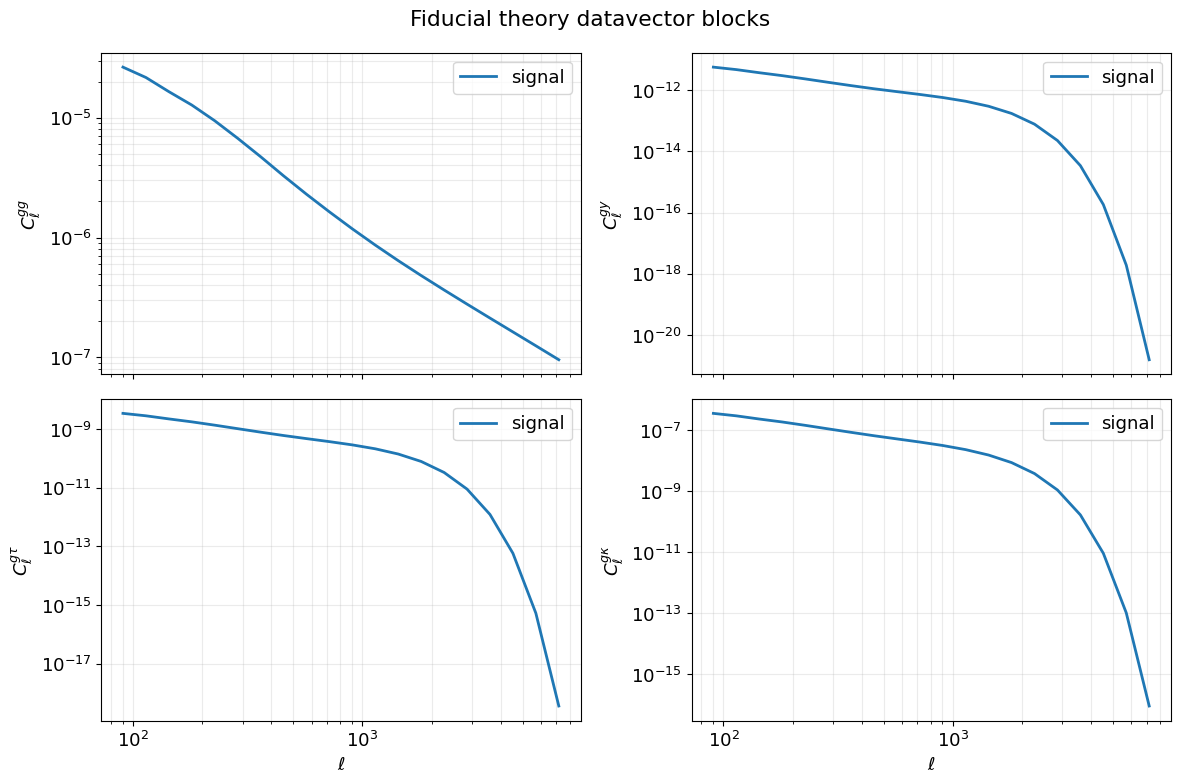

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ax, spec, ylabel in zip(
    axes.ravel(),
    ["gg", "gy", "gtau", "gkappa"],
    [r"$C_\ell^{gg}$", r"$C_\ell^{gy}$", r"$C_\ell^{g\tau}$", r"$C_\ell^{g\kappa}$"],
):
    y = np.asarray(cl[spec])
    ax.loglog(ell, np.abs(y), lw=2, label="signal")
    ax.set_ylabel(ylabel)
    ax.grid(True, which="both", alpha=0.25)
    ax.legend()
for ax in axes[-1]:
    ax.set_xlabel(r"$\ell$")
fig.suptitle("Fiducial theory datavector blocks")
fig.tight_layout()

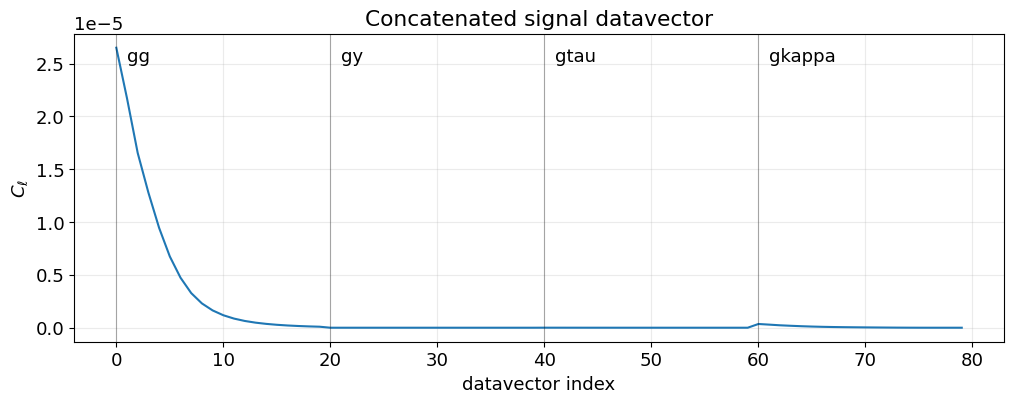

In [4]:
dv = theory["data_vector"]
nell = len(ell)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(np.arange(len(dv)), dv, lw=1.5)
for i, spec in enumerate(theory["spectra_order"]):
    ax.axvline(i * nell, color="k", lw=0.8, alpha=0.3)
    ax.text(i * nell + 0.05 * nell, np.nanmax(dv), spec, va="top")
ax.set_xlabel("datavector index")
ax.set_ylabel(r"$C_\ell$")
ax.set_title("Concatenated signal datavector")
ax.grid(alpha=0.25)

{
  "finite": true,
  "symmetric_max_abs": 0.0,
  "positive_diagonal": true,
  "min_eigenvalue": 1.0496313036506365e-28,
  "max_eigenvalue": 2.433733840306661e-12,
  "condition_number": 2.318655924077427e+16
}


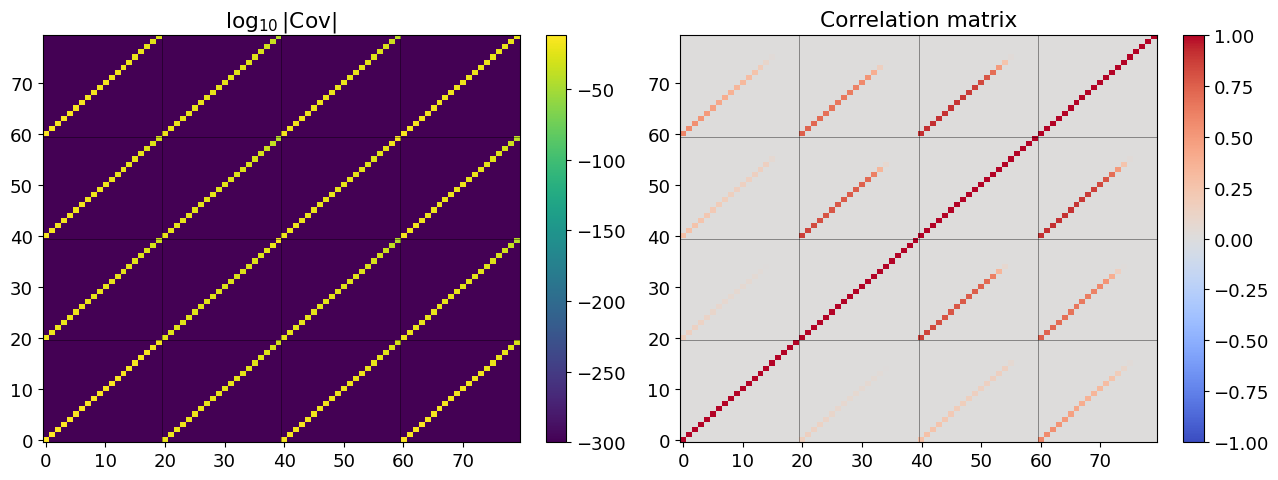

In [5]:
cov = theory["cov"]
corr = theory["corr"]
checks = covariance_quality_checks(cov)
print(json.dumps(checks, indent=2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
im0 = axes[0].imshow(np.log10(np.abs(cov) + 1e-300), origin="lower", aspect="auto")
axes[0].set_title(r"$\log_{10}|\mathrm{Cov}|$")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(corr, origin="lower", aspect="auto", vmin=-1, vmax=1, cmap="coolwarm")
axes[1].set_title("Correlation matrix")
plt.colorbar(im1, ax=axes[1], fraction=0.046)
for ax in axes:
    for i in range(1, len(theory["spectra_order"])):
        ax.axhline(i * nell - 0.5, color="k", lw=0.7, alpha=0.4)
        ax.axvline(i * nell - 0.5, color="k", lw=0.7, alpha=0.4)
fig.tight_layout()

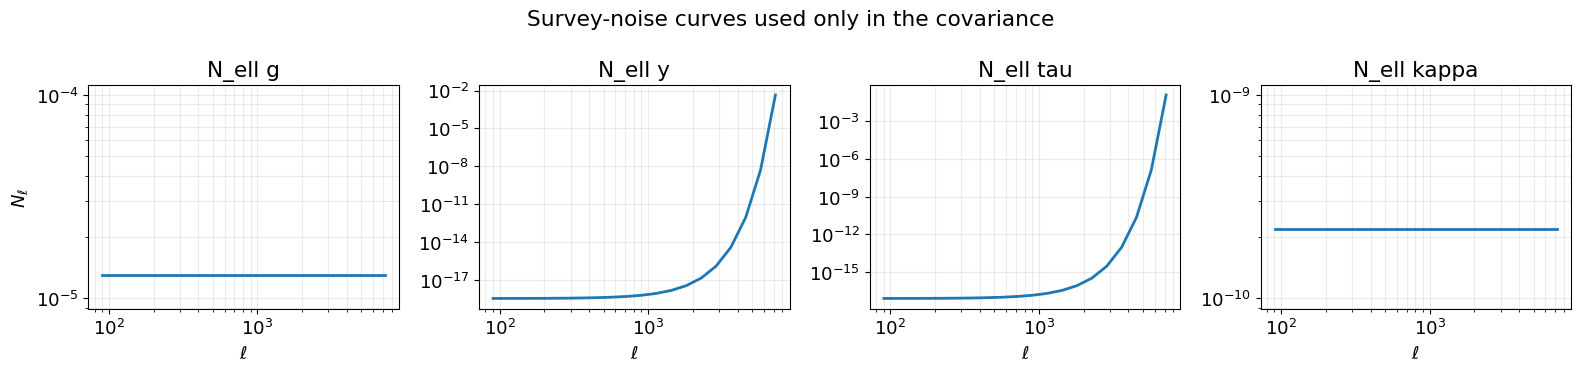

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), sharex=True)
for ax, field in zip(axes, ["g", "y", "tau", "kappa"]):
    ax.loglog(ell, np.abs(noise[field]), lw=2)
    ax.set_title(f"N_ell {field}")
    ax.grid(True, which="both", alpha=0.25)
    ax.set_xlabel(r"$\ell$")
axes[0].set_ylabel(r"$N_\ell$")
fig.suptitle("Survey-noise curves used only in the covariance")
fig.tight_layout()

In [7]:
def map_validation_needs_regeneration(path):
    path = Path(path)
    if not path.exists():
        return True
    try:
        product = load_map_validation_product(path)
    except Exception as exc:
        print(f"Will regenerate map validation because it could not be loaded: {exc}")
        return True
    meta = product["metadata"]
    if not meta.get("backlight_mass_metadata"):
        print("Will regenerate map validation because it lacks Backlight mass metadata.")
        return True
    map_meta = meta.get("map_metadata", {})
    if map_meta.get("field_accumulation_version") != "single_add_v2":
        print("Will regenerate map validation because the pasted maps predate the single-add field accumulation fix.")
        return True
    expected_factor = BACKLIGHT_SETTINGS["mass_metadata"]["theory_mass_factor_applied"]
    found_factor = map_meta.get("theory_mass_factor_applied")
    if found_factor is None or not np.isclose(float(found_factor), expected_factor, rtol=1e-6):
        print("Will regenerate map validation because the pasted maps use the old mass convention.")
        return True
    if meta.get("theory_path") != str(THEORY_OUTPUT):
        print("Will regenerate map validation because it points at a different theory product.")
        return True
    return False

if REGENERATE_MAP_VALIDATION or map_validation_needs_regeneration(MAP_VALIDATION_OUTPUT):
    measure_pasted_map_cls(
        theory_path=THEORY_OUTPUT,
        map_path=DEFAULT_MAP_PATH,
        halo_catalog=DEFAULT_HALO_CATALOG,
        output_path=MAP_VALIDATION_OUTPUT,
        nside=NSIDE,
        gal_zmin=GAL_ZMIN,
        gal_zmax=GAL_ZMAX,
        regenerate_maps=REGENERATE_PASTED_MAPS,
    )

mapval = load_map_validation_product(MAP_VALIDATION_OUTPUT)
arr = mapval["arrays"]
meta = mapval["metadata"]
print(f"Loaded map validation product: {MAP_VALIDATION_OUTPUT}")
print(json.dumps(meta, indent=2)[:5000])

Loaded map validation product: /mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/SBI_validate/outputs/pasted_map_cls_validation_nside512.npz
{
  "availability": {
    "gg": {
      "available": true,
      "map_key": "galaxy_counts",
      "reason": ""
    },
    "gkappa": {
      "available": true,
      "map_key": "map_kappa",
      "reason": ""
    },
    "grhom": {
      "available": true,
      "map_key": "map_rhom",
      "reason": "map_rhom is not a lensing-weighted kappa map"
    },
    "gtau": {
      "available": true,
      "map_key": "map_tau",
      "reason": ""
    },
    "gy": {
      "available": true,
      "map_key": "map_ymap",
      "reason": ""
    }
  },
  "backlight_mass_metadata": {
    "raw_mass_column": "M200c",
    "raw_mass_max": 1589715572621312.0,
    "raw_mass_min": 10001098735616.0,
    "theory_mass_factor_applied": 0.8509140610694885,
    "theory_mass_max": 1352711333844608.0,
    "theory_mass_min": 8510075540279.9375,
    "theory_mass_unit": "Msun_ov

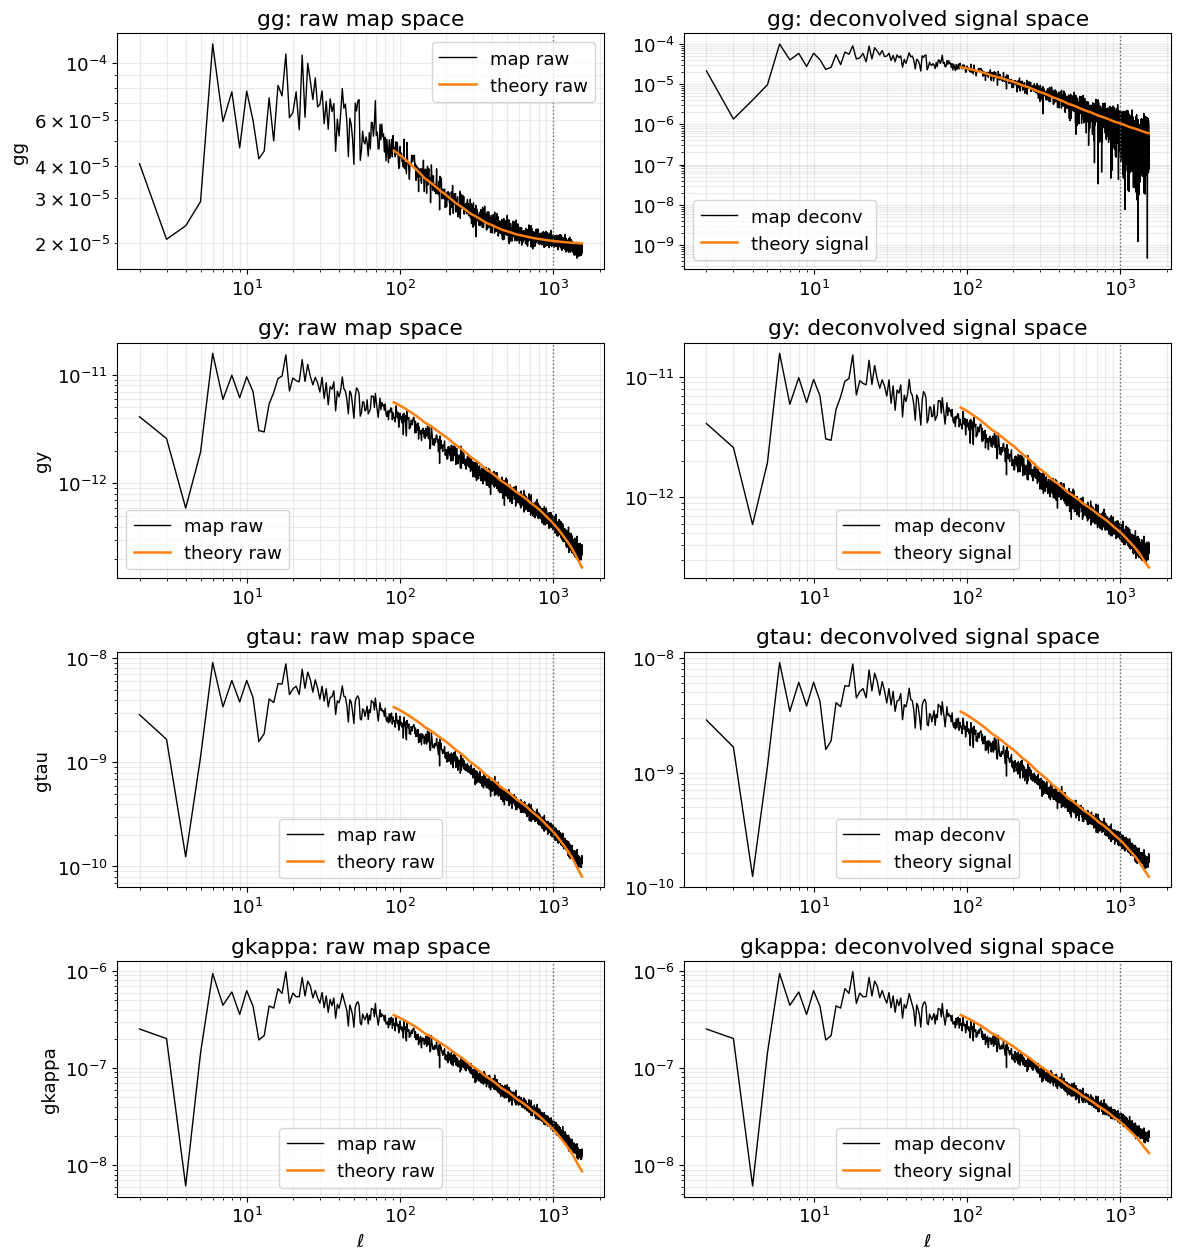

In [8]:
ell_int = arr["ell_int"]
ell_max_compare = meta.get("ell_max_compare", 1000.0)
available_specs = [s for s in ["gg", "gy", "gtau", "gkappa"] if f"{s}_signal_map" in arr]

fig, axes = plt.subplots(len(available_specs), 2, figsize=(12, 3.2 * len(available_specs)), squeeze=False)
for row, spec in enumerate(available_specs):
    ax_raw, ax_sig = axes[row]
    ax_raw.loglog(ell_int[2:], np.abs(arr[f"{spec}_raw_map"][2:]), color="k", lw=1, label="map raw")
    ax_raw.loglog(ell_int[2:], np.abs(arr[f"{spec}_raw_theory"][2:]), color="C1", lw=1.8, label="theory raw")
    ax_raw.set_ylabel(spec)
    ax_raw.set_title(f"{spec}: raw map space")
    ax_raw.axvline(ell_max_compare, color="0.4", ls=":", lw=1)
    ax_raw.grid(True, which="both", alpha=0.25)
    ax_raw.legend()

    ax_sig.loglog(ell_int[2:], np.abs(arr[f"{spec}_signal_map"][2:]), color="k", lw=1, label="map deconv")
    ax_sig.loglog(ell_int[2:], np.abs(arr[f"{spec}_signal_theory"][2:]), color="C1", lw=1.8, label="theory signal")
    ax_sig.set_title(f"{spec}: deconvolved signal space")
    ax_sig.axvline(ell_max_compare, color="0.4", ls=":", lw=1)
    ax_sig.grid(True, which="both", alpha=0.25)
    ax_sig.legend()
for ax in axes[-1]:
    ax.set_xlabel(r"$\ell$")
fig.tight_layout()

if "gkappa" not in available_specs:
    print("gkappa map validation skipped:", meta["availability"].get("gkappa", {}).get("reason", "not available"))

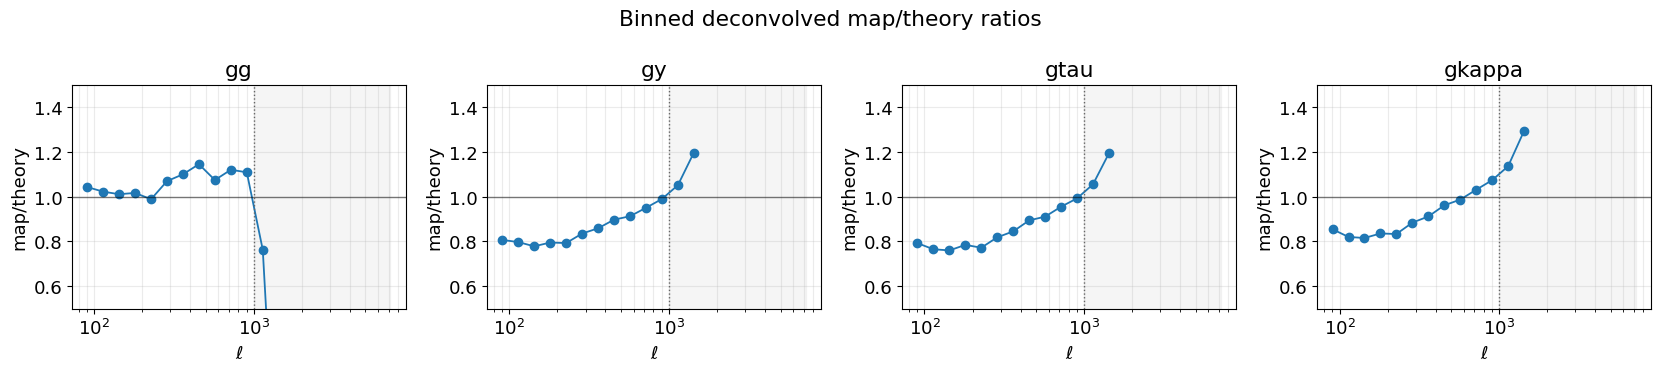

In [9]:
fig, axes = plt.subplots(1, len(available_specs), figsize=(4.2 * len(available_specs), 3.8), squeeze=False)
for ax, spec in zip(axes.ravel(), available_specs):
    m = arr[f"{spec}_signal_map_binned"]
    t = arr[f"{spec}_signal_theory_binned"]
    ratio = m / np.where(np.abs(t) > 1e-300, t, np.nan)
    ax.semilogx(ell, ratio, marker="o", lw=1.3)
    ax.axhline(1.0, color="k", lw=1, alpha=0.5)
    ax.axvline(ell_max_compare, color="0.4", ls=":", lw=1)
    ax.axvspan(ell_max_compare, np.nanmax(ell), color="0.7", alpha=0.12)
    ax.set_title(spec)
    ax.set_xlabel(r"$\ell$")
    ax.set_ylabel("map/theory")
    ax.set_ylim(0.5, 1.5)
    ax.grid(True, which="both", alpha=0.25)
fig.suptitle("Binned deconvolved map/theory ratios")
fig.tight_layout()

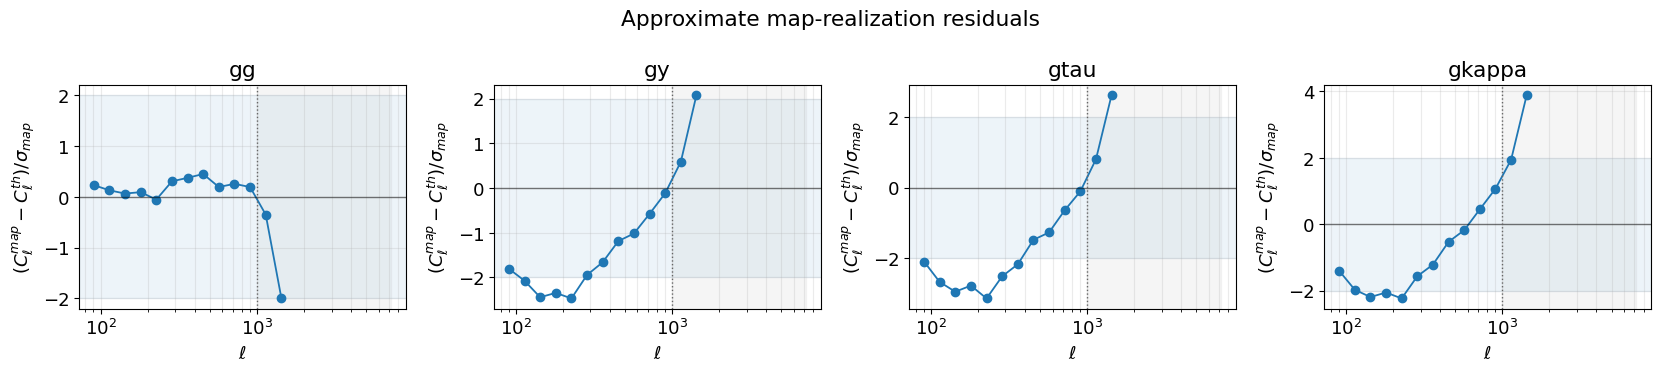

In [10]:
fig, axes = plt.subplots(1, len(available_specs), figsize=(4.2 * len(available_specs), 3.8), squeeze=False)
for ax, spec in zip(axes.ravel(), available_specs):
    m = arr[f"{spec}_signal_map_binned"]
    t = arr[f"{spec}_signal_theory_binned"]
    sig = arr[f"{spec}_signal_sigma_binned"]
    resid = (m - t) / np.where(sig > 0, sig, np.nan)
    ax.semilogx(ell, resid, marker="o", lw=1.3)
    ax.axhline(0.0, color="k", lw=1, alpha=0.5)
    ax.axhspan(-2, 2, color="C0", alpha=0.08)
    ax.axvline(ell_max_compare, color="0.4", ls=":", lw=1)
    ax.axvspan(ell_max_compare, np.nanmax(ell), color="0.7", alpha=0.12)
    ax.set_title(spec)
    ax.set_xlabel(r"$\ell$")
    ax.set_ylabel(r"$(C_\ell^{map}-C_\ell^{th})/\sigma_{map}$")
    ax.grid(True, which="both", alpha=0.25)
fig.suptitle("Approximate map-realization residuals")
fig.tight_layout()

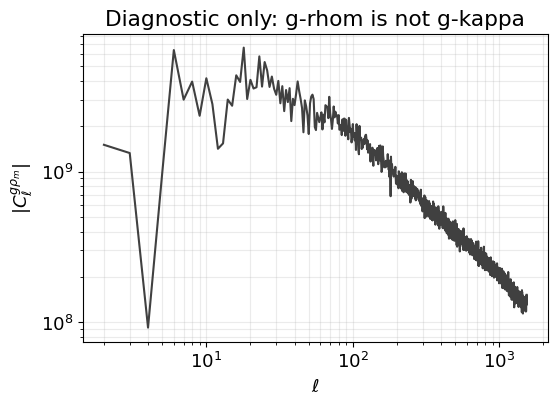

In [11]:
if "grhom_signal_map" in arr:
    plt.figure(figsize=(6, 4))
    plt.loglog(arr["ell_int"][2:], np.abs(arr["grhom_signal_map"][2:]), color="0.25")
    plt.xlabel(r"$\ell$")
    plt.ylabel(r"$|C_\ell^{g\rho_m}|$")
    plt.title("Diagnostic only: g-rhom is not g-kappa")
    plt.grid(True, which="both", alpha=0.25)
else:
    print("No map_rhom diagnostic found in this map product.")

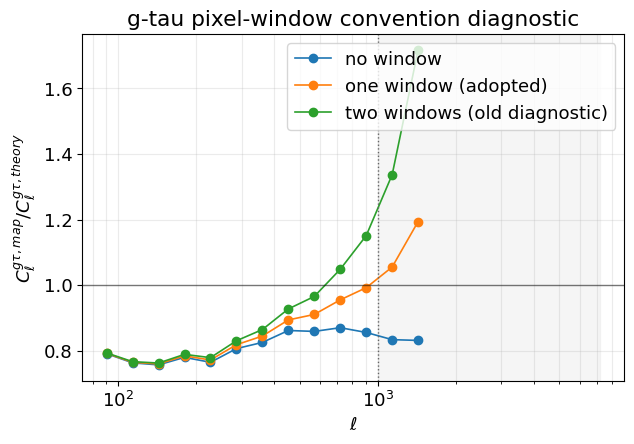

In [12]:
if "gtau_signal_map_no_window_binned" in arr:
    t = arr["gtau_signal_theory_binned"]
    variants = {
        "no window": arr["gtau_signal_map_no_window_binned"],
        "one window (adopted)": arr["gtau_signal_map_binned"],
        "two windows (old diagnostic)": arr["gtau_signal_map_two_window_binned"],
    }
    plt.figure(figsize=(7, 4.5))
    for label, mvar in variants.items():
        ratio = mvar / np.where(np.abs(t) > 1e-300, t, np.nan)
        plt.semilogx(ell, ratio, marker="o", lw=1.2, label=label)
    plt.axhline(1.0, color="k", lw=1, alpha=0.5)
    plt.axvline(ell_max_compare, color="0.4", ls=":", lw=1)
    plt.axvspan(ell_max_compare, np.nanmax(ell), color="0.7", alpha=0.12)
    plt.xlabel(r"$\ell$")
    plt.ylabel(r"$C_\ell^{g\tau, map}/C_\ell^{g\tau, theory}$")
    plt.title("g-tau pixel-window convention diagnostic")
    plt.grid(True, which="both", alpha=0.25)
    plt.legend()
else:
    print("Run map validation again to create g-tau window diagnostic arrays.")

Theory mode: map_matched_resolved
Map-derived calibrations applied: False
Ratio diagnostics: {'gg': {'ell_max': 800.0, 'ell_min': 300.0, 'median_map_over_theory': 1.1103521985553562, 'n_bins': 4, 'p16_map_over_theory': 1.0869132087228084, 'p84_map_over_theory': 1.1333952340755826}, 'gkappa': {'ell_max': 800.0, 'ell_min': 300.0, 'median_map_over_theory': 0.9743947846104555, 'n_bins': 4, 'p16_map_over_theory': 0.9356811210759953, 'p84_map_over_theory': 1.0101062594846397}, 'gtau': {'ell_max': 800.0, 'ell_min': 300.0, 'median_map_over_theory': 0.9026888842986067, 'n_bins': 4, 'p16_map_over_theory': 0.8687561208295214, 'p84_map_over_theory': 0.9341497138033809}, 'gy': {'ell_max': 800.0, 'ell_min': 300.0, 'median_map_over_theory': 0.9051622219718627, 'n_bins': 4, 'p16_map_over_theory': 0.8774708081995639, 'p84_map_over_theory': 0.9323838720427053}}
Halo-only gkappa theory is saved as theory_gkappa_resolved_8r200c_binned.
Map-side gkappa validation still requires a true source-weighted map_k

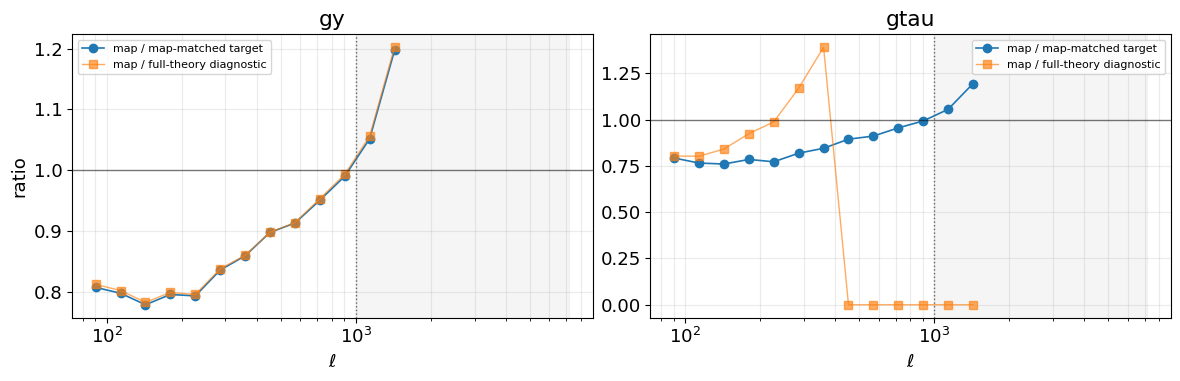

In [13]:
print("Theory mode:", meta.get("theory_mode"))
print("Map-derived calibrations applied:", meta.get("map_derived_calibrations_applied", False))
print("Ratio diagnostics:", meta.get("map_theory_ratio_diagnostics", {}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for ax, spec in zip(axes, ["gy", "gtau"]):
    target = arr[f"{spec}_signal_theory_binned"]
    ratio = arr[f"{spec}_signal_map_binned"] / np.where(np.abs(target) > 1e-300, target, np.nan)
    ax.semilogx(ell, ratio, marker="o", lw=1.2, label="map / map-matched target")
    full_key = f"theory_{spec}_full_binned"
    if full_key in arr:
        full_ratio = arr[f"{spec}_signal_map_binned"] / np.where(np.abs(arr[full_key]) > 1e-300, arr[full_key], np.nan)
        ax.semilogx(ell, full_ratio, marker="s", lw=1.0, alpha=0.65, label="map / full-theory diagnostic")
    ax.axhline(1.0, color="k", lw=1, alpha=0.5)
    ax.axvline(ell_max_compare, color="0.4", ls=":", lw=1)
    ax.axvspan(ell_max_compare, np.nanmax(ell), color="0.7", alpha=0.12)
    ax.set_title(spec)
    ax.set_xlabel(r"$\ell$")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(fontsize=8)
axes[0].set_ylabel("ratio")
fig.tight_layout()

if "theory_gkappa_resolved_8r200c_binned" in arr:
    print("Halo-only gkappa theory is saved as theory_gkappa_resolved_8r200c_binned.")
    print("Map-side gkappa validation still requires a true source-weighted map_kappa product.")